# 04 Exotic Options: Asian and Barrier

European and American options in notebooks 01-03 depend only on the terminal price (or allow exercise at any time). This notebook covers two path-dependent exotic priced via Monte Carlo.  

1. **Asian options** — payoff depends on the average price, average strike along the path (4 variants incorporating 2 different average methods, arithmetic & geometric)
2. **Barrier options** — payoff depends on whether the path touches a barrier level (4 knock-in/knock-out with up/down direction variants )

Key validation tools used:
- Geometric Asian options have a closed-form benchmark
- In-out parity (knock-in + knock-out = vanilla) is model-free and must hold exactly regardless of barrier level

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import matplotlib.pyplot as plt

from src.engines.analytical import BSMModel
from src.models.equity.gbm import GBMModel
from src.products.asian import AsianOption
from src.products.barrier import BarrierOption

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## Asian Options: Average Price vs Average Strike

We simulate a single set of GBM paths and reuse them to price both Asian variants, plus the geometric closed-form benchmark.

- **Average price**: `max(A - K, 0)` — fixed strike, average price replaces the terminal price $S_T$
- **Average strike**: `max(S_T - A, 0)` — floating strike replaced by the average strike

In [2]:
S, K, T, r, sigma, q = 100, 100, 1, 0.05, 0.2, 0

model = GBMModel(S0=S, r=r, sigma=sigma, q=q)
paths = model.simulate(T=T, n_paths=300_000, n_steps=252, seed=926)

opt_avg_price  = AsianOption(S, K, T, r, sigma, q, "call", averaging="price",  average_type="arithmetic")
opt_avg_strike = AsianOption(S, K, T, r, sigma, q, "call", averaging="strike", average_type="arithmetic")

disc = np.exp(-r * T)
price_avg_price  = disc * float(np.mean(opt_avg_price.payoff(paths)))
price_avg_strike = disc * float(np.mean(opt_avg_strike.payoff(paths)))
bsm_price = float(BSMModel(S, K, T, r, sigma, q).price("call"))

print(f"European (BSM) : {bsm_price:.4f}")
print(f"Asian, average price : {price_avg_price:.4f}")
print(f"Asian, average strike : {price_avg_strike:.4f}")

European (BSM) : 10.4506
Asian, average price : 5.7215
Asian, average strike : 5.8576


Both Asian variants are cheaper than the European option. Averaging the path reduces the effective volatility of the payoff-determining quantity (the averagge of N correlated log-normal draws has lower variance than a single terminal draw), so the option that depends on an average is worth less than one depending on the raw terminal price.

## Closed-Form Validation: Geometric Average Asian

The arithmetic average of a GBM path is not log-normal, so there is no exact closed form for the standard arithmetic Asian option. The geometric average, however, is log-normal, has an exact BSM-style formula solution. We use it to validate our Monte Carlo payoff implementation independent of any MC noise concerns about the arithmetic case.

In [3]:
opt_geo = AsianOption(S, K, T, r, sigma, q, "call", averaging="price", average_type="geometric")

closed_form_price = opt_geo.analytical_price_geometric()
mc_geo_price = disc * float(np.mean(opt_geo.payoff(paths)))

print(f"Kemna-Vorst closed-form : {closed_form_price:.6f}")
print(f"Monte Carlo (same paths): {mc_geo_price:.6f}")
print(f"Error : {abs(closed_form_price - mc_geo_price):.4f}")


Kemna-Vorst closed-form : 5.546819
Monte Carlo (same paths): 5.505719
Error : 0.0411


Close agreement here confirms the Asian payoff logic itself is correct.

##  Visualizing the Averaging Effect

We pick a single simulated path and show the raw price path alongside its running average, which is exactly the quantity the Asian payoff depends on.

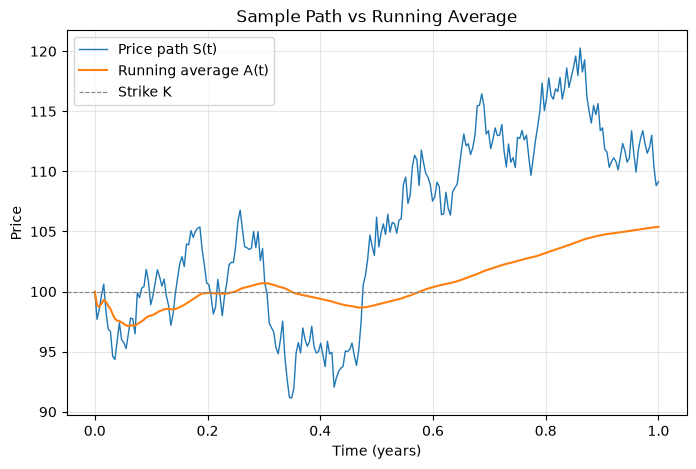

Terminal price S_T : 109.16
Final average A_T : 105.38


In [4]:
path = paths[8] # arbitrary
running_avg = np.cumsum(path) / np.arange(1, len(path) + 1)
t_axis = np.linspace(0, T, len(path))

fig, ax = plt.subplots()
ax.plot(t_axis, path, label="Price path S(t)", lw=1)
ax.plot(t_axis, running_avg, label="Running average A(t)", lw=1.5)
ax.axhline(K, color="gray", linestyle="--", lw=0.8, label="Strike K")
ax.set_xlabel("Time (years)")
ax.set_ylabel("Price")
ax.set_title("Sample Path vs Running Average")
ax.legend()
plt.show()

print(f"Terminal price S_T : {path[-1]:.2f}")
print(f"Final average A_T : {running_avg[-1]:.2f}")

The running average is visibly smoother than the raw path because it counts the whole history rather than just the final value, which is precisely why averaging dampens the effective volatility seen by the option.

## Barrier Options: All Four Variants

A barrier option's payoff depends on whether the path ever touches a barrier level B. We price all four combinations (up / down * in / out) on the same set of simulated paths, using an up-barrier at 120 and a down-barrier at 80 (both 20% away from spot).

In [5]:
configs = [
    ("up-and-out", 120, "call"),
    ("up-and-in", 120, "call"),
    ("down-and-out", 80, "put"),
    ("down-and-in", 80, "put"),
]

print(f"{'Variant':<16} {'Barrier':>8} {'Price':>10}")
print("-" * 38)
barrier_prices = {}
for barrier_type, B, opt_type in configs:
    opt = BarrierOption(S, K, T, r, sigma, barrier=B, barrier_type=barrier_type, q=q, option_type=opt_type)
    price = disc * float(np.mean(opt.payoff(paths)))
    barrier_prices[barrier_type] = price
    print(f"{barrier_type:<16} {B:>8} {price:>10.4f}")

print()
print(f"{'Vanilla call (BSM)':<16} {'--':>8} {bsm_price:>10.4f}")
bsm_put = float(BSMModel(S, K, T, r, sigma, q).price('put'))
print(f"{'Vanilla put (BSM)':<16} {'--':>8} {bsm_put:>10.4f}")

Variant           Barrier      Price
--------------------------------------
up-and-out            120     1.3362
up-and-in             120     9.0748
down-and-out           80     1.7521
down-and-in            80     3.8291

Vanilla call (BSM)       --    10.4506
Vanilla put (BSM)       --     5.5735


##  In-Out Parity Check

Every path either touches the barrier or doesn't, which means knock-in and knock-out are mutually exclusive and exhaustive. 

```
knock-in price + knock-out price = vanilla price
```

This is model-free. The in-out parity holds regardless of barrier level, volatility, or even which model generated the paths. It's one of the strongest sanity checks available for barrier option code, because it doesn't rely on comparing against any other pricing method.

In [6]:
up_sum = barrier_prices["up-and-out"] + barrier_prices["up-and-in"]
down_sum = barrier_prices["down-and-out"] + barrier_prices["down-and-in"]

print(f"Up: KO={barrier_prices['up-and-out']:.4f} + KI={barrier_prices['up-and-in']:.4f} = {up_sum:.4f}   (vanilla call = {bsm_price:.4f})")
print(f"Down: KO={barrier_prices['down-and-out']:.4f} + KI={barrier_prices['down-and-in']:.4f} = {down_sum:.4f}   (vanilla put  = {bsm_put:.4f})")

print()
print(f"Up parity error : {abs(up_sum - bsm_price):.4f}")
print(f"Down parity error : {abs(down_sum - bsm_put):.4f}")

Up: KO=1.3362 + KI=9.0748 = 10.4109   (vanilla call = 10.4506)
Down: KO=1.7521 + KI=3.8291 = 5.5812   (vanilla put  = 5.5735)

Up parity error : 0.0396
Down parity error : 0.0077


##  Barrier Price vs Barrier Level

As the up-barrier moves further from spot, knock-out should approach the vanilla price because barrier is rarely touched. Whereas knock-in should approach zero because barrier is rarely activated. The two curves should always sum to vanilla price.

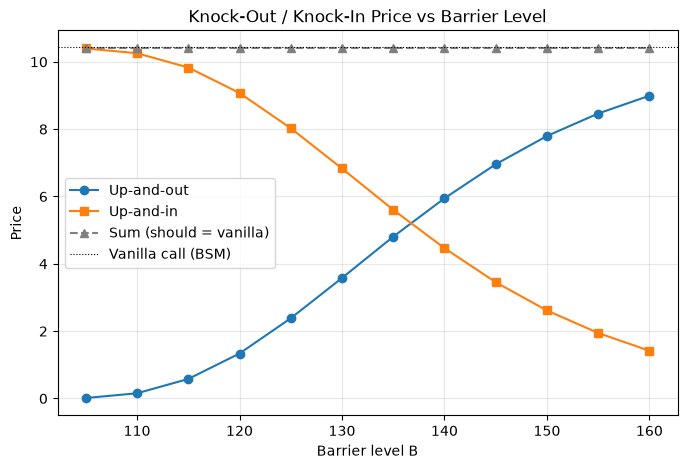

In [7]:
barrier_levels = np.arange(105, 161, 5)

ko_prices = []
ki_prices = []

for B in barrier_levels:
    opt_ko = BarrierOption(S, K, T, r, sigma, barrier=B, barrier_type="up-and-out", q=q, option_type="call")
    opt_ki = BarrierOption(S, K, T, r, sigma, barrier=B, barrier_type="up-and-in", q=q, option_type="call")
    ko_prices.append(disc * float(np.mean(opt_ko.payoff(paths))))
    ki_prices.append(disc * float(np.mean(opt_ki.payoff(paths))))

ko_prices = np.array(ko_prices)
ki_prices = np.array(ki_prices)

fig, ax = plt.subplots()
ax.plot(barrier_levels, ko_prices, marker="o", label="Up-and-out")
ax.plot(barrier_levels, ki_prices, marker="s", label="Up-and-in")
ax.plot(barrier_levels, ko_prices + ki_prices, marker="^", linestyle="--", color="gray", label="Sum (should = vanilla)")
ax.axhline(bsm_price, color="black", linestyle=":", lw=0.8, label="Vanilla call (BSM)")
ax.set_xlabel("Barrier level B")
ax.set_ylabel("Price")
ax.set_title("Knock-Out / Knock-In Price vs Barrier Level")
ax.legend()
plt.show()

As B moves further above spot: knock-out rises toward the vanilla price (less likely to be extinguished), knock-in falls toward zero (less likely to be activated), and their sum tracks the vanilla price line closely at every barrier level — confirming in-out parity holds not just at one point but across the whole range.

## Summary

| Check | Result |
|---|---|
| Asian average price vs European | 5.7215 vs 10.4506 — averaging reduces value |
| Asian average strike vs European | 5.8576 vs 10.4506 |
| Geometric Asian: closed-form vs MC | Error 0.0411 (Kemna-Vorst benchmark) |
| Up barrier in-out parity | KO + KI = 10.4109 vs vanilla 10.4506 (err 0.0396) |
| Down barrier in-out parity | KO + KI = 5.5812 vs vanilla 5.5735 (err 0.0077) |
| Parity across barrier levels | Sum tracks vanilla price at every B tested |